In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
stocks = pd.read_csv("historical_stocks.csv")
prices = pd.read_csv("historical_stock_prices.csv")

# Preview
print(stocks.head())
print(prices.head())

print(prices.info())

  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  
  ticker   open  close  adj_close    low   high   volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   1

In [3]:
# Check missing values
print(prices.isnull().sum())

# Convert date column
prices['date'] = pd.to_datetime(prices['date'])

# Sort values
prices = prices.sort_values(by=['ticker', 'date'])

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [4]:
# Forward fill (time-series friendly)
prices = prices.groupby('ticker').apply(lambda x: x.fillna(method='ffill')).reset_index(drop=True)

# Backward fill if needed
prices = prices.groupby('ticker').apply(lambda x: x.fillna(method='bfill')).reset_index(drop=True)

# Final check
print(prices.isnull().sum())

C:\Users\ECG\AppData\Local\Temp\ipykernel_22100\1190552132.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prices = prices.groupby('ticker').apply(lambda x: x.fillna(method='ffill')).reset_index(drop=True)
C:\Users\ECG\AppData\Local\Temp\ipykernel_22100\1190552132.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prices = prices.groupby('ticker').apply(lambda x: x.fillna(method='ffill')).reset_index(drop=True)
C:\Users\ECG\AppData\Local\Temp\ipykernel_22100\1190552132.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() i

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


In [5]:
# Using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply to key columns
prices = remove_outliers(prices, 'close')
prices = remove_outliers(prices, 'volume')

In [6]:
# Remove negative prices/volume (invalid data)
prices = prices[(prices['close'] > 0) & (prices['volume'] > 0)]

# Remove duplicates
prices = prices.drop_duplicates()

print("Cleaned shape:", prices.shape)

Cleaned shape: (16557818, 8)


In [7]:
prices['MA_7'] = prices.groupby('ticker')['close'].transform(lambda x: x.rolling(7).mean())
prices['MA_30'] = prices.groupby('ticker')['close'].transform(lambda x: x.rolling(30).mean())

In [8]:
prices['volatility'] = prices.groupby('ticker')['close'].transform(lambda x: x.rolling(7).std())

In [9]:
prices['daily_return'] = prices.groupby('ticker')['close'].pct_change()

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = ['close', 'volume', 'MA_7', 'MA_30', 'volatility', 'daily_return']

prices[num_cols] = scaler.fit_transform(prices[num_cols])

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
prices['ticker_encoded'] = le.fit_transform(prices['ticker'])

# Drop original ticker
prices = prices.drop(columns=['ticker'])

In [13]:
# Drop rows with NaN values created from rolling calculations
prices = prices.dropna()

print("Shape after dropping NaNs:", prices.shape)

Shape after dropping NaNs: (16395162, 12)


In [14]:
X = prices.drop(columns=['close'])  # features
y = prices['close']                 # target

print(X.shape, y.shape)

(16395162, 11) (16395162,)


In [15]:
from sklearn.model_selection import train_test_split

# First split (Train vs Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

# Second split (Validation vs Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (11476613, 11)
Validation: (2459274, 11)
Test: (2459275, 11)


In [16]:
X_train.to_csv("X_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

prices.to_csv("cleaned_stock_data.csv", index=False)

print("All datasets saved successfully")

All datasets saved successfully


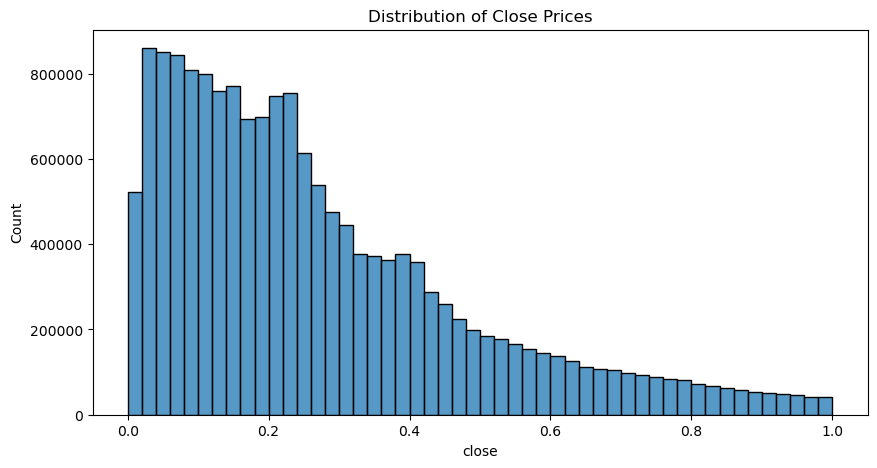

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(prices['close'], bins=50)
plt.title("Distribution of Close Prices")
plt.show()

### “Due to the high cardinality of the ticker variable, label encoding was used instead of one-hot encoding to ensure memory efficiency and scalability.”

In [18]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16395162 entries, 977 to 20973888
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   open            float64       
 1   close           float64       
 2   adj_close       float64       
 3   low             float64       
 4   high            float64       
 5   volume          float64       
 6   date            datetime64[ns]
 7   MA_7            float64       
 8   MA_30           float64       
 9   volatility      float64       
 10  daily_return    float64       
 11  ticker_encoded  int32         
dtypes: datetime64[ns](1), float64(10), int32(1)
memory usage: 1.5 GB
